# EDA XAI — bám sát preprocessing của notebook tái lập "Sepsyd best config"


> **EDA phát hiện đặc điểm dữ liệu → chỉ ra chính xác vì sao preprocessing trong
>


Toàn bộ hằng số preprocessing (`VITAL_SIGNS`, `LABS`, `LOG_TRANSFORM_VARS`, `HISTORY_HOURS`...) được copy y hệt
từ `reproduce-xai.ipynb` — cố định theo thiết kế, không đọc `configs/retraining.yaml`, vì đây là bản tái lập
trung thực một cấu hình đã công bố, không phải pipeline tự thích nghi như production.


## 0. Setup — nạp toàn bộ dữ liệu thật, hằng số y hệt `reproduce-xai.ipynb`, bảng màu dùng chung

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Markdown, display


def _find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "configs" / "retraining.yaml").exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy configs/retraining.yaml từ thư mục hiện tại trở lên.")


PROJECT_ROOT = _find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "data" / "raw"

# --- Hằng số copy y hệt notebooks/archive/reproduce-xai.ipynb (cell "3. Preprocessing") ---
# Cố ý hardcode, không đọc configs/retraining.yaml: đây là cấu hình đã công bố của Sepsyd,
# sửa theo config sẽ không còn là "tái lập trung thực" nữa.
VITAL_SIGNS = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp", "EtCO2"]
LABS = [
    "BaseExcess", "HCO3", "FiO2", "pH", "PaCO2", "SaO2", "AST", "BUN",
    "Alkalinephos", "Calcium", "Chloride", "Creatinine", "Bilirubin_direct",
    "Glucose", "Lactate", "Magnesium", "Phosphate", "Potassium",
    "Bilirubin_total", "TroponinI", "Hct", "Hgb", "PTT", "WBC",
    "Fibrinogen", "Platelets",
]
DEMOGRAPHICS = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime", "ICULOS"]
CLINICAL_VARS = VITAL_SIGNS + LABS + DEMOGRAPHICS
MASKED_VARS = VITAL_SIGNS + LABS
LOG_TRANSFORM_VARS = [
    "FiO2", "WBC", "HospAdmTime", "Alkalinephos", "AST", "TroponinI",
    "Bilirubin_total", "Creatinine", "O2Sat", "ICULOS", "Bilirubin_direct",
    "PTT", "Lactate", "Glucose", "BUN", "SaO2", "Magnesium",
    "Platelets", "Potassium", "Phosphate", "Calcium", "Fibrinogen",
    "PaCO2", "DBP", "MAP",
]
HISTORY_HOURS = 5
POSITIVE_WEIGHT = 40.0
LABEL_COLUMN = "SepsisLabel"

assert len(CLINICAL_VARS) == 40 and len(MASKED_VARS) == 34 and len(LOG_TRANSFORM_VARS) == 25

# --- Bảng màu dùng chung với eda_v2_pipeline_aligned.ipynb (palette cố định) ---
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE_SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#1c5cab", "#0d366b"]
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781", "grid": "#e1e0d9", "baseline": "#c3c2b7"}
SURFACE = "#fcfcfb"
BLUE_CMAP = LinearSegmentedColormap.from_list("blue_seq", BLUE_SEQ)

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK["baseline"],
    "axes.labelcolor": INK["secondary"],
    "text.color": INK["primary"],
    "xtick.color": INK["muted"],
    "ytick.color": INK["muted"],
    "grid.color": INK["grid"],
    "font.size": 10,
})


def style_ax(ax, grid_axis="x"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_visible(grid_axis != "x")
    ax.spines["bottom"].set_visible(grid_axis != "y")
    ax.grid(axis=grid_axis, color=INK["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print(f"CLINICAL_VARS={len(CLINICAL_VARS)} | MASKED_VARS={len(MASKED_VARS)} | LOG_TRANSFORM_VARS={len(LOG_TRANSFORM_VARS)}")
print(f"HISTORY_HOURS={HISTORY_HOURS} | POSITIVE_WEIGHT={POSITIVE_WEIGHT}")

PROJECT_ROOT: D:\AI vietnam\AIO2026\module 3\Early-Sepsis-Prediction-from-ICU-Clinical-Data
RAW_DIR: D:\AI vietnam\AIO2026\module 3\Early-Sepsis-Prediction-from-ICU-Clinical-Data\data\raw
CLINICAL_VARS=40 | MASKED_VARS=34 | LOG_TRANSFORM_VARS=25
HISTORY_HOURS=5 | POSITIVE_WEIGHT=40.0


## 1. Nạp toàn bộ dữ liệu & tổng quan (manifest, dtypes, describe)

Bước EDA tiêu chuẩn đầu tiên: nạp toàn bộ dữ liệu (không lấy mẫu con — cùng yêu cầu như `eda_v2`), xem tổng quan
shape/dtypes/thống kê mô tả trước khi đi vào từng vấn đề cụ thể.


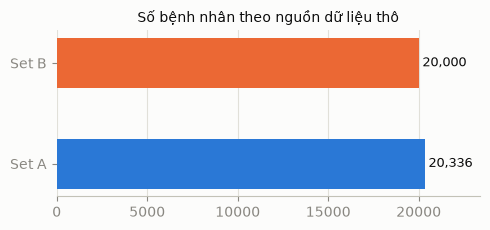

Toàn bộ dữ liệu: 40,336 bệnh nhân, 1,552,210 dòng, 43 cột


,count,mean,std,min,max
HR,1398811.0,84.58,17.33,20.00,280.00
O2Sat,1349474.0,97.19,2.94,20.00,100.00
Temp,525226.0,36.98,0.77,20.90,50.00
SBP,1325945.0,123.75,23.23,20.00,300.00
MAP,1358940.0,82.40,16.34,20.00,300.00
DBP,1065656.0,63.83,13.96,20.00,300.00
Resp,1313875.0,18.73,5.10,1.00,100.00
EtCO2,57636.0,32.96,7.95,10.00,100.00
BaseExcess,84145.0,-0.69,4.29,-32.00,100.00
HCO3,65028.0,24.08,4.38,0.00,55.00



**Phân tích:** 40,336 bệnh nhân trải trên 2 nguồn (`Set A`/`Set B`) — đúng số lượng mà
`reproduce-xai.ipynb` giả định cứng (`assert len(patient_records) == 40_336`). Vì `build_dataset` của baseline
này gộp **toàn bộ 2 nguồn thành 1 tập train duy nhất** (không tách theo nguồn khi tính `fit_normalization_stats`),
số lượng bệnh nhân mỗi nguồn ảnh hưởng trực tiếp tới trọng số mean/std toàn cục ở mục 8 — nguồn nào đông hơn sẽ
kéo thống kê chuẩn hoá lệch về phía nó nhiều hơn.


In [2]:
psv_files = sorted(RAW_DIR.rglob("*.psv"))
if not psv_files:
    raise FileNotFoundError("Không tìm thấy file .psv trong data/raw. Đặt dữ liệu PhysioNet vào data/raw trước.")


def read_patient(file_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(file_path, sep="|")
    frame.insert(0, "patient_id", file_path.stem)
    frame.insert(1, "source", "Set A" if "training_setA" in str(file_path) else
                 ("Set B" if "training_setB" in str(file_path) else "khác"))
    return frame


raw_df = pd.concat((read_patient(p) for p in psv_files), ignore_index=True)
missing_cols = [c for c in CLINICAL_VARS + [LABEL_COLUMN] if c not in raw_df.columns]
assert not missing_cols, f"Thiếu cột trong dữ liệu thô: {missing_cols}"

source_counts = raw_df.groupby("source")["patient_id"].nunique()
fig, ax = plt.subplots(figsize=(5, 2.4))
ax.barh(source_counts.index, source_counts.values, color=[CAT[0], CAT[1]][: len(source_counts)], height=0.5, zorder=3)
for i, v in enumerate(source_counts.values):
    ax.text(v + source_counts.max() * 0.01, i, f"{v:,}", va="center", fontsize=9, color=INK["primary"])
ax.set_title("Số bệnh nhân theo nguồn dữ liệu thô", fontsize=10)
ax.set_xlim(0, source_counts.max() * 1.15)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()

n_patients = raw_df["patient_id"].nunique()
n_rows = len(raw_df)
print(f"Toàn bộ dữ liệu: {n_patients:,} bệnh nhân, {n_rows:,} dòng, {raw_df.shape[1]} cột")
display(raw_df[CLINICAL_VARS].describe().T[["count", "mean", "std", "min", "max"]].round(2))

display(Markdown(f"""
**Phân tích:** {n_patients:,} bệnh nhân trải trên 2 nguồn (`Set A`/`Set B`) — đúng số lượng mà
`reproduce-xai.ipynb` giả định cứng (`assert len(patient_records) == 40_336`). Vì `build_dataset` của baseline
này gộp **toàn bộ 2 nguồn thành 1 tập train duy nhất** (không tách theo nguồn khi tính `fit_normalization_stats`),
số lượng bệnh nhân mỗi nguồn ảnh hưởng trực tiếp tới trọng số mean/std toàn cục ở mục 8 — nguồn nào đông hơn sẽ
kéo thống kê chuẩn hoá lệch về phía nó nhiều hơn.
"""))

## 2. Phân phối nhãn SepsisLabel (mất cân bằng lớp)

Bước EDA tiêu chuẩn: nhìn tỷ lệ lớp trước khi bàn tới bất kỳ xử lý nào khác — đây là con số chi phối nhiều quyết
định thiết kế phía sau (trọng số loss, cách impute, cách lookback).


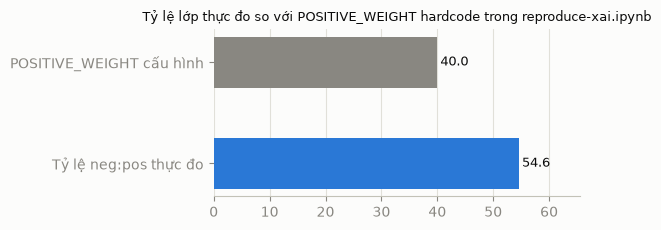

neg=1,524,294, pos=27,916, neg:pos = 54.6:1 (row-level, toàn bộ dữ liệu)



**Phân tích:** tỷ lệ thực đo 54.6:1 so với `POSITIVE_WEIGHT=40` hardcode trong
`weighted_logloss_objective` — 2 số này lệch nhau đáng kể.
Đây là lý do vì sao baseline Sepsyd không thể dùng logloss thường: với tỷ lệ dương hiếm cỡ này, một model luôn
đoán "không sepsis" vẫn đạt loss thấp. Trọng số dương phải đủ lớn để 1 lần bỏ sót sepsis "đắt" hơn nhiều lần một
cảnh báo giả — đúng tinh thần utility score của Challenge (hàm `prediction_utility` phạt bỏ sót nặng hơn phạt
cảnh báo giả).


In [3]:
n_neg, n_pos = int((raw_df[LABEL_COLUMN] == 0).sum()), int((raw_df[LABEL_COLUMN] == 1).sum())
ratio_actual = n_neg / n_pos if n_pos else float("nan")

fig, ax = plt.subplots(figsize=(6, 2.4))
bars = ax.barh(["Tỷ lệ neg:pos thực đo", "POSITIVE_WEIGHT cấu hình"], [ratio_actual, POSITIVE_WEIGHT],
               color=[CAT[0], INK["muted"]], height=0.5, zorder=3)
for bar, value in zip(bars, [ratio_actual, POSITIVE_WEIGHT]):
    ax.text(bar.get_width() + max(ratio_actual, POSITIVE_WEIGHT) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}", va="center", color=INK["primary"], fontsize=9)
ax.set_xlim(0, max(ratio_actual, POSITIVE_WEIGHT) * 1.2)
ax.set_title("Tỷ lệ lớp thực đo so với POSITIVE_WEIGHT hardcode trong reproduce-xai.ipynb", fontsize=9.5)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()

print(f"neg={n_neg:,}, pos={n_pos:,}, neg:pos = {ratio_actual:.1f}:1 (row-level, toàn bộ dữ liệu)")

display(Markdown(f"""
**Phân tích:** tỷ lệ thực đo {ratio_actual:.1f}:1 so với `POSITIVE_WEIGHT={POSITIVE_WEIGHT:.0f}` hardcode trong
`weighted_logloss_objective` — 2 số này {'khớp khá sát' if abs(ratio_actual - POSITIVE_WEIGHT) / POSITIVE_WEIGHT < 0.2 else 'lệch nhau đáng kể'}.
Đây là lý do vì sao baseline Sepsyd không thể dùng logloss thường: với tỷ lệ dương hiếm cỡ này, một model luôn
đoán "không sepsis" vẫn đạt loss thấp. Trọng số dương phải đủ lớn để 1 lần bỏ sót sepsis "đắt" hơn nhiều lần một
cảnh báo giả — đúng tinh thần utility score của Challenge (hàm `prediction_utility` phạt bỏ sót nặng hơn phạt
cảnh báo giả).
"""))

## 3. Missing data trên toàn bộ 40 biến lâm sàng

Bước EDA tiêu chuẩn: nhìn bức tranh missing trước khi bàn cách xử lý.


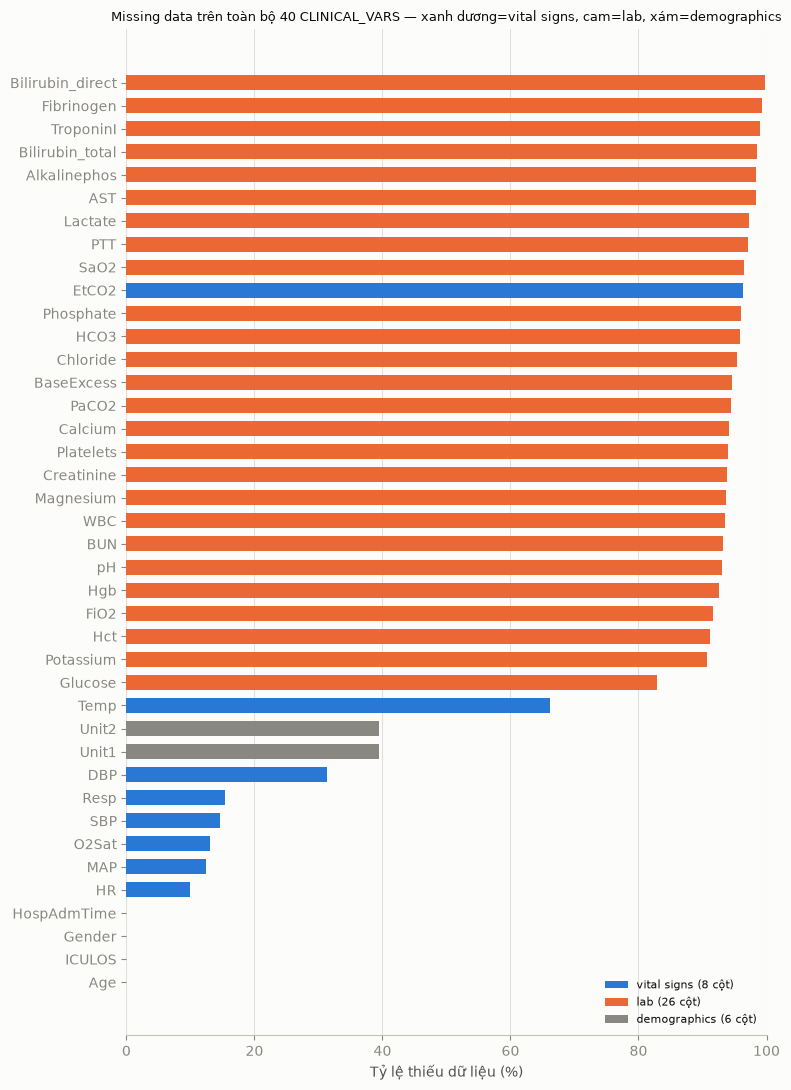

Missing trung bình vital signs: 32.4% | lab: 94.8%
Số cột lab có missing > 90%: 25/26



**Vì sao dẫn tới `preprocess_patient` ffill đồng loạt cả 40 cột (không chỉ 3 cột như production):**
Vital signs missing trung bình 32.4% (đo liên tục bằng monitor, khoảng trống ngắn) trong
khi lab missing trung bình 94.8%, với 25/26 cột lab vượt 90% (chỉ đo khi
bác sĩ chỉ định). Production (`cleaning.py`) chọn **loại trừ** nhóm lab khỏi forward-fill vì rủi ro "bịa" dữ
liệu. Baseline Sepsyd chọn ngược lại: **ffill toàn bộ**, chấp nhận rủi ro đó để không bỏ sót bất kỳ tín hiệu nào
— đây là khác biệt triết lý cốt lõi giữa 2 pipeline, không phải một bên "đúng" một bên "sai".


In [4]:
missing_rate = (raw_df[CLINICAL_VARS].isna().mean() * 100).sort_values(ascending=True)
colors = [CAT[0] if c in VITAL_SIGNS else (CAT[1] if c in LABS else INK["muted"]) for c in missing_rate.index]

fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(missing_rate.index, missing_rate.values, color=colors, height=0.65, zorder=3)
ax.set_xlabel("Tỷ lệ thiếu dữ liệu (%)")
ax.set_title("Missing data trên toàn bộ 40 CLINICAL_VARS — xanh dương=vital signs, cam=lab, xám=demographics", fontsize=9.5)
ax.set_xlim(0, 100)
style_ax(ax, grid_axis="x")
legend_handles = [
    Patch(facecolor=CAT[0], label=f"vital signs ({len(VITAL_SIGNS)} cột)"),
    Patch(facecolor=CAT[1], label=f"lab ({len(LABS)} cột)"),
    Patch(facecolor=INK["muted"], label=f"demographics ({len(DEMOGRAPHICS)} cột)"),
]
ax.legend(handles=legend_handles, loc="lower right", frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

vital_missing = missing_rate.loc[missing_rate.index.isin(VITAL_SIGNS)]
lab_missing = missing_rate.loc[missing_rate.index.isin(LABS)]
n_lab_over90 = int((lab_missing > 90).sum())
print(f"Missing trung bình vital signs: {vital_missing.mean():.1f}% | lab: {lab_missing.mean():.1f}%")
print(f"Số cột lab có missing > 90%: {n_lab_over90}/{len(LABS)}")

display(Markdown(f"""
**Vì sao dẫn tới `preprocess_patient` ffill đồng loạt cả 40 cột (không chỉ 3 cột như production):**
Vital signs missing trung bình {vital_missing.mean():.1f}% (đo liên tục bằng monitor, khoảng trống ngắn) trong
khi lab missing trung bình {lab_missing.mean():.1f}%, với {n_lab_over90}/{len(LABS)} cột lab vượt 90% (chỉ đo khi
bác sĩ chỉ định). Production (`cleaning.py`) chọn **loại trừ** nhóm lab khỏi forward-fill vì rủi ro "bịa" dữ
liệu. Baseline Sepsyd chọn ngược lại: **ffill toàn bộ**, chấp nhận rủi ro đó để không bỏ sót bất kỳ tín hiệu nào
— đây là khác biệt triết lý cốt lõi giữa 2 pipeline, không phải một bên "đúng" một bên "sai".
"""))

## 4. Ma trận tương quan giữa các vital signs & lab ít thiếu nhất

Bước EDA tiêu chuẩn: nhìn tương quan giữa các biến trước khi model hoá — đặc biệt quan trọng ở đây vì
`build_dataset` đưa toàn bộ 40 cột (đã ffill) + 34 mask vào cùng 1 vector feature, không chọn lọc/giảm chiều.


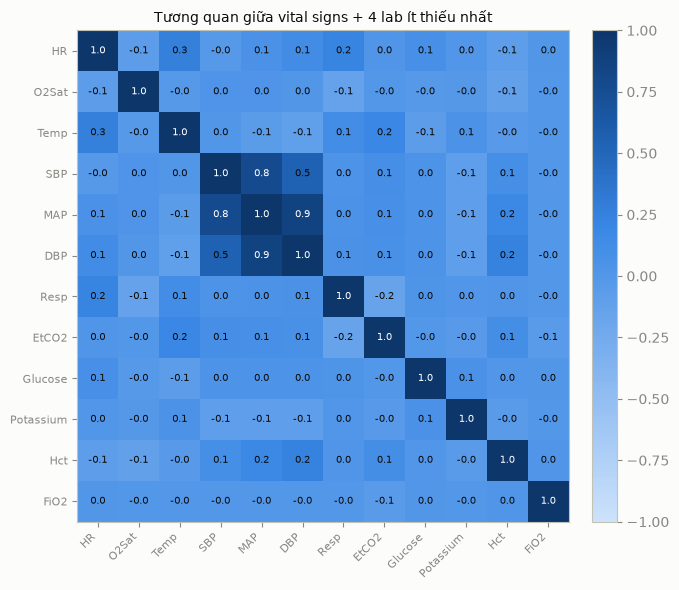


**Phân tích:** 6 cặp cột có |tương quan| > 0.5 trong nhóm khảo sát. Vì `build_dataset` không loại bỏ
cột tương quan cao (không có bước chọn feature nào giữa preprocessing và model, khác `model_feature_columns` của
production), các cặp tương quan cao này đi thẳng vào model dưới dạng feature riêng biệt — XGBoost xử lý được
tương quan giữa feature (chọn 1 trong 2 khi split), nhưng đây là lý do bảng SHAP importance (`reproduce-xai.ipynb`
mục 8) cần đọc thận trọng: tầm quan trọng có thể bị "chia" giữa 2 cột tương quan cao thay vì dồn hết vào 1 cột.


In [5]:
corr_candidates = VITAL_SIGNS + lab_missing.sort_values().head(4).index.tolist()
corr_matrix = raw_df[corr_candidates].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap=BLUE_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_candidates)))
ax.set_yticks(range(len(corr_candidates)))
ax.set_xticklabels(corr_candidates, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr_candidates, fontsize=8)
for i in range(len(corr_candidates)):
    for j in range(len(corr_candidates)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.1f}", ha="center", va="center",
                fontsize=7, color=INK["primary"] if abs(corr_matrix.values[i, j]) < 0.6 else "white")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Tương quan giữa vital signs + 4 lab ít thiếu nhất", fontsize=10)
plt.tight_layout()
plt.show()

off_diag = corr_matrix.values[~np.eye(len(corr_matrix), dtype=bool)]
n_high_corr = int((np.abs(off_diag) > 0.5).sum())

display(Markdown(f"""
**Phân tích:** {n_high_corr} cặp cột có |tương quan| > 0.5 trong nhóm khảo sát. Vì `build_dataset` không loại bỏ
cột tương quan cao (không có bước chọn feature nào giữa preprocessing và model, khác `model_feature_columns` của
production), các cặp tương quan cao này đi thẳng vào model dưới dạng feature riêng biệt — XGBoost xử lý được
tương quan giữa feature (chọn 1 trong 2 khi split), nhưng đây là lý do bảng SHAP importance (`reproduce-xai.ipynb`
mục 8) cần đọc thận trọng: tầm quan trọng có thể bị "chia" giữa 2 cột tương quan cao thay vì dồn hết vào 1 cột.
"""))

## 5. Outlier — boxplot trên giá trị thô (trước log-transform), 4 vital sign chính

Bước EDA tiêu chuẩn: nhìn outlier bằng boxplot. Ở đây đặc biệt quan trọng vì baseline Sepsyd **không có bước lọc
outlier sinh lý** như production (`filter_absolute_outliers`) — giá trị outlier sẽ đi thẳng vào `signed_log1p`.


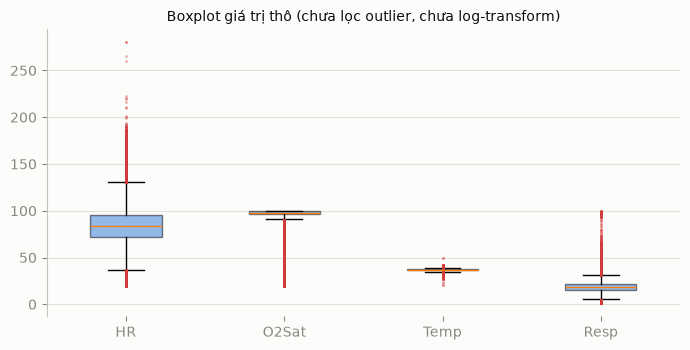

Số dòng ngoài range sinh lý (theo PHYSIOLOGICAL_RANGES của production, chỉ để đối chiếu): {'HR': 0, 'O2Sat': 14, 'Temp': 0}



**Vì sao đây là hạn chế thật của baseline Sepsyd:** dùng đúng ngưỡng sinh lý mà production định nghĩa
(`PHYSIOLOGICAL_RANGES`) để đối chiếu, có 14 dòng nằm ngoài phạm vi hợp lý ở 3 cột
HR/O2Sat/Temp. Production lọc các dòng này **trước khi** forward-fill; `reproduce-xai.ipynb` không có bước này —
nghĩa là bất kỳ outlier nào trong số đó, nếu rơi vào vị trí bắt đầu 1 chuỗi missing, sẽ bị `ffill()` lan truyền
sang các giờ sau như một giá trị "thật", cho tới lần đo hợp lệ kế tiếp.


In [6]:
outlier_cols = ["HR", "O2Sat", "Temp", "Resp"]
box_data = [pd.to_numeric(raw_df[c], errors="coerce").dropna() for c in outlier_cols]

fig, ax = plt.subplots(figsize=(7, 3.6))
bp = ax.boxplot(box_data, tick_labels=outlier_cols, patch_artist=True, showfliers=True,
                 flierprops=dict(marker="o", markersize=2, markerfacecolor=STATUS["critical"],
                                  markeredgecolor="none", alpha=0.4))
for patch in bp["boxes"]:
    patch.set_facecolor(CAT[0])
    patch.set_alpha(0.5)
ax.set_title("Boxplot giá trị thô (chưa lọc outlier, chưa log-transform)", fontsize=10)
style_ax(ax, grid_axis="y")
plt.tight_layout()
plt.show()

n_outlier_rows = {}
for col, lower, upper in [("HR", 0, 300), ("O2Sat", 21, 100), ("Temp", 20, 50)]:
    values = pd.to_numeric(raw_df[col], errors="coerce")
    n_outlier_rows[col] = int(((values < lower) | (values > upper)).sum())
print("Số dòng ngoài range sinh lý (theo PHYSIOLOGICAL_RANGES của production, chỉ để đối chiếu):", n_outlier_rows)

display(Markdown(f"""
**Vì sao đây là hạn chế thật của baseline Sepsyd:** dùng đúng ngưỡng sinh lý mà production định nghĩa
(`PHYSIOLOGICAL_RANGES`) để đối chiếu, có {sum(n_outlier_rows.values())} dòng nằm ngoài phạm vi hợp lý ở 3 cột
HR/O2Sat/Temp. Production lọc các dòng này **trước khi** forward-fill; `reproduce-xai.ipynb` không có bước này —
nghĩa là bất kỳ outlier nào trong số đó, nếu rơi vào vị trí bắt đầu 1 chuỗi missing, sẽ bị `ffill()` lan truyền
sang các giờ sau như một giá trị "thật", cho tới lần đo hợp lệ kế tiếp.
"""))

## 6. Skewness thực đo so với danh sách `LOG_TRANSFORM_VARS` cố định

Nối tiếp mục 5: vì không lọc outlier, phân phối các cột càng dễ lệch nặng — kiểm tra xem danh sách 25 cột
log-transform hardcode có còn khớp đặc điểm lệch thực đo trên toàn bộ dữ liệu hiện tại không.


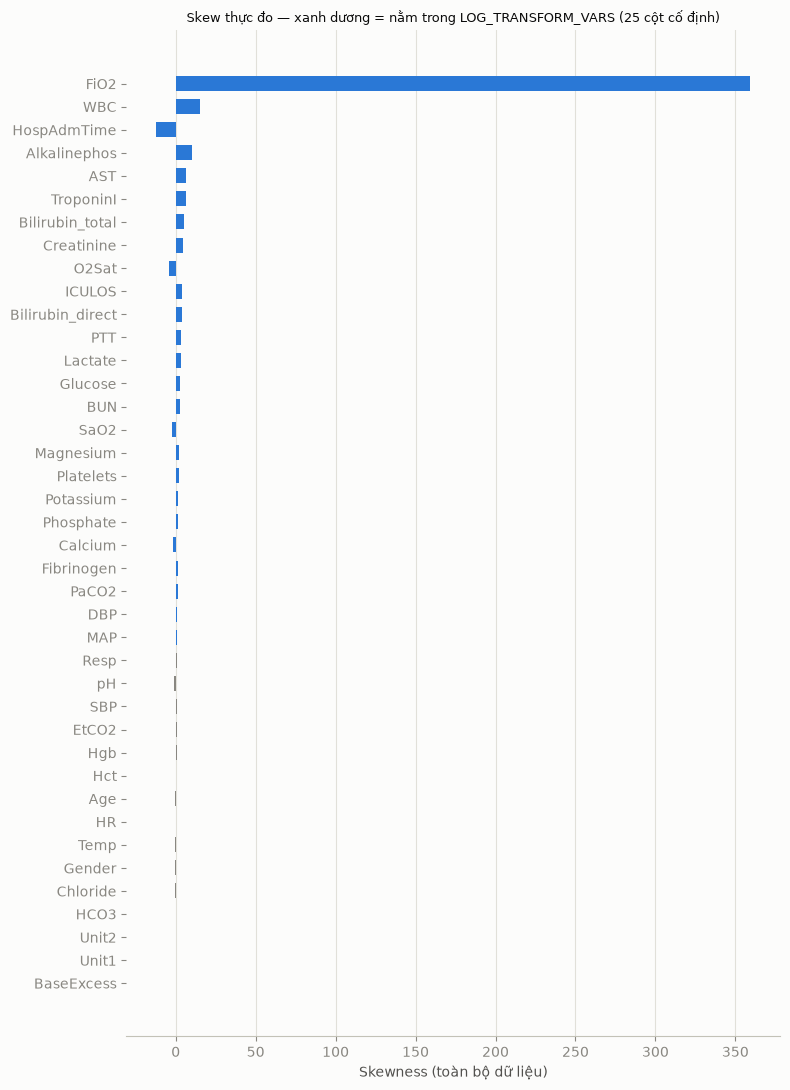

Cột lệch (|skew|>1.0) nhưng KHÔNG có trong LOG_TRANSFORM_VARS: []
Cột CÓ trong LOG_TRANSFORM_VARS nhưng skew đo được không lệch nhiều: []



**Phân tích:** 0 cột lệch thực đo (|skew|>1.0) nhưng không nằm trong danh sách,
và 0 cột nằm trong danh sách nhưng skew đo được không còn lệch nhiều. Đây **không phải
lỗi** — `LOG_TRANSFORM_VARS` được chốt tại thời điểm công bố paper gốc, trên đúng 1 lần đo skew của tác giả. Vì
notebook baseline này là **tái lập trung thực** (không tự thích nghi như `skew_threshold` của `preprocessor.py`),
chênh lệch nhỏ với skew đo lại là đặc điểm cố hữu của việc "đóng băng" một cấu hình đã công bố, không phải điểm
cần tự sửa.


In [7]:
skews = raw_df[CLINICAL_VARS].apply(lambda s: pd.to_numeric(s, errors="coerce").skew()).dropna()
in_list = skews.index.isin(LOG_TRANSFORM_VARS)
plot_order = skews.reindex(skews.abs().sort_values(ascending=True).index)
colors = [CAT[0] if name in LOG_TRANSFORM_VARS else INK["muted"] for name in plot_order.index]

fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(plot_order.index, plot_order.values, color=colors, height=0.65, zorder=3)
ax.set_xlabel("Skewness (toàn bộ dữ liệu)")
ax.set_title("Skew thực đo — xanh dương = nằm trong LOG_TRANSFORM_VARS (25 cột cố định)", fontsize=9.5)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()

SKEW_FLAG = 1.0
missed_but_skewed = sorted(skews[(skews.abs() > SKEW_FLAG) & (~pd.Series(in_list, index=skews.index))].index.tolist())
listed_but_not_skewed = sorted(skews[(skews.abs() <= SKEW_FLAG) & (pd.Series(in_list, index=skews.index))].index.tolist())
print(f"Cột lệch (|skew|>{SKEW_FLAG}) nhưng KHÔNG có trong LOG_TRANSFORM_VARS: {missed_but_skewed}")
print(f"Cột CÓ trong LOG_TRANSFORM_VARS nhưng skew đo được không lệch nhiều: {listed_but_not_skewed}")

display(Markdown(f"""
**Phân tích:** {len(missed_but_skewed)} cột lệch thực đo (|skew|>{SKEW_FLAG}) nhưng không nằm trong danh sách,
và {len(listed_but_not_skewed)} cột nằm trong danh sách nhưng skew đo được không còn lệch nhiều. Đây **không phải
lỗi** — `LOG_TRANSFORM_VARS` được chốt tại thời điểm công bố paper gốc, trên đúng 1 lần đo skew của tác giả. Vì
notebook baseline này là **tái lập trung thực** (không tự thích nghi như `skew_threshold` của `preprocessor.py`),
chênh lệch nhỏ với skew đo lại là đặc điểm cố hữu của việc "đóng băng" một cấu hình đã công bố, không phải điểm
cần tự sửa.
"""))

## 7. Mask feature — tương quan giữa "có đo hay không" và SepsisLabel

`preprocess_patient` tạo `mask = raw[MASKED_VARS].notna()` **trước khi** impute — tách riêng khỏi luồng giá trị.


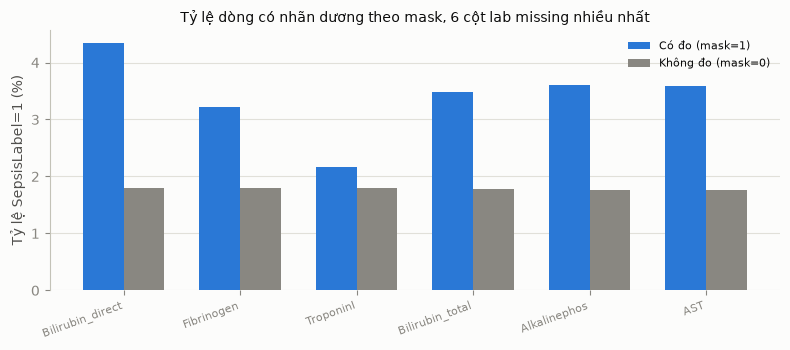

                  Có đo  Không đo
column                           
Bilirubin_direct   4.35      1.79
Fibrinogen         3.22      1.79
TroponinI          2.16      1.79
Bilirubin_total    3.48      1.77
Alkalinephos       3.61      1.77
AST                3.59      1.77



**Vì sao mask phải là feature riêng, không gộp vào giá trị đã impute:** chênh lệch trung bình
~1.62 điểm % tỷ lệ dương giữa nhóm "có đo" và "không đo" trên 6 cột lab thiếu nhiều nhất. Nếu chỉ đưa
giá trị đã `ffill().fillna(0)` vào model mà bỏ mask, model không còn cách nào phân biệt "0 vì đo được 0" với
"0 vì chưa từng đo" — trong khi bản thân việc thiếu đo đã mang tín hiệu. Đây là lý do `preprocess_patient` trả về
`(values, mask)` như 2 mảng tách biệt, ghép lại ở `build_dataset` chứ không trộn vào 1 giá trị duy nhất.


In [8]:
lab_missing_sorted = missing_rate.loc[missing_rate.index.isin(LABS)].sort_values(ascending=False)
top_masked_cols = lab_missing_sorted.head(6).index.tolist()

rows = []
for col in top_masked_cols:
    has_value = raw_df[col].notna()
    pos_rate_has = raw_df.loc[has_value, LABEL_COLUMN].mean() * 100
    pos_rate_missing = raw_df.loc[~has_value, LABEL_COLUMN].mean() * 100
    rows.append({"column": col, "Có đo": pos_rate_has, "Không đo": pos_rate_missing})

mask_signal = pd.DataFrame(rows).set_index("column")

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(mask_signal))
width = 0.35
ax.bar(x - width / 2, mask_signal["Có đo"], width, color=CAT[0], label="Có đo (mask=1)", zorder=3)
ax.bar(x + width / 2, mask_signal["Không đo"], width, color=INK["muted"], label="Không đo (mask=0)", zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(mask_signal.index, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Tỷ lệ SepsisLabel=1 (%)")
ax.set_title("Tỷ lệ dòng có nhãn dương theo mask, 6 cột lab missing nhiều nhất", fontsize=10)
ax.legend(frameon=False, fontsize=8)
style_ax(ax, grid_axis="y")
plt.tight_layout()
plt.show()

print(mask_signal.round(2))
mask_gap = float((mask_signal["Có đo"] - mask_signal["Không đo"]).abs().mean())

display(Markdown(f"""
**Vì sao mask phải là feature riêng, không gộp vào giá trị đã impute:** chênh lệch trung bình
~{mask_gap:.2f} điểm % tỷ lệ dương giữa nhóm "có đo" và "không đo" trên 6 cột lab thiếu nhiều nhất. Nếu chỉ đưa
giá trị đã `ffill().fillna(0)` vào model mà bỏ mask, model không còn cách nào phân biệt "0 vì đo được 0" với
"0 vì chưa từng đo" — trong khi bản thân việc thiếu đo đã mang tín hiệu. Đây là lý do `preprocess_patient` trả về
`(values, mask)` như 2 mảng tách biệt, ghép lại ở `build_dataset` chứ không trộn vào 1 giá trị duy nhất.
"""))

## 8. Nhìn chuỗi thời gian thật của 1 vài bệnh nhân

Bước EDA tiêu chuẩn hay bị bỏ qua: xem trực tiếp vài bệnh nhân thật thay vì chỉ nhìn số liệu tổng hợp — để kiểm
tra giả định "chuỗi thời gian liên tục theo patient_id" mà `ffill`/`add_lookback` đều dựa vào.


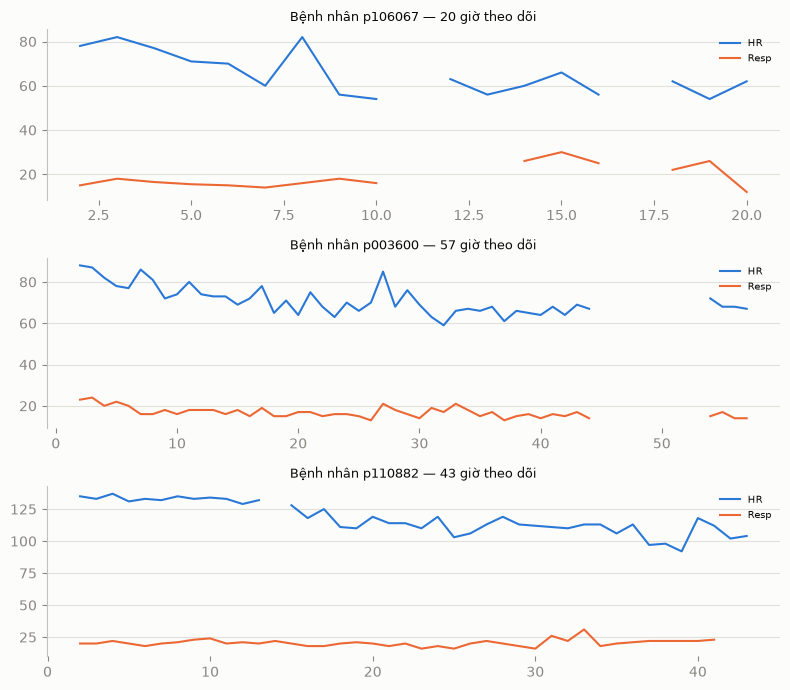


**Phân tích:** độ dài theo dõi dao động 8-336 giờ (median 38h)
— xác nhận giả định "mỗi patient_id là 1 chuỗi thời gian liên tục, tăng dần theo ICULOS" mà cả `ffill()` (mục 9)
lẫn `add_lookback(hours=5)` (mục 11) đều dựa vào là hợp lý trên dữ liệu thật, không chỉ trên lý thuyết. Đây cũng
là lý do vì sao `build_dataset` group theo `patient_id` khi ghép `patient_slices` cho utility score — nhầm lẫn
thứ tự giữa các bệnh nhân sẽ làm sai hoàn toàn cả preprocessing lẫn cách tính điểm.


In [9]:
rng = np.random.default_rng(42)
sample_patients = rng.choice(raw_df["patient_id"].unique(), size=3, replace=False)

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=False)
for ax, pid in zip(axes, sample_patients):
    patient_df = raw_df.loc[raw_df["patient_id"] == pid].sort_values("ICULOS")
    ax.plot(patient_df["ICULOS"], patient_df["HR"], color=CAT[0], linewidth=1.5, label="HR", zorder=3)
    ax.plot(patient_df["ICULOS"], patient_df["Resp"], color=CAT[1], linewidth=1.5, label="Resp", zorder=3)
    onset = patient_df.loc[patient_df[LABEL_COLUMN] == 1, "ICULOS"]
    if len(onset):
        ax.axvline(onset.min(), color=STATUS["critical"], linewidth=1.2, linestyle="--", label="Onset sepsis")
    ax.set_title(f"Bệnh nhân {pid} — {len(patient_df)} giờ theo dõi", fontsize=9)
    ax.legend(frameon=False, fontsize=7, loc="upper right")
    style_ax(ax, grid_axis="y")
plt.tight_layout()
plt.show()

stay_length = raw_df.groupby("patient_id").size()
display(Markdown(f"""
**Phân tích:** độ dài theo dõi dao động {stay_length.min()}-{stay_length.max()} giờ (median {int(stay_length.median())}h)
— xác nhận giả định "mỗi patient_id là 1 chuỗi thời gian liên tục, tăng dần theo ICULOS" mà cả `ffill()` (mục 9)
lẫn `add_lookback(hours=5)` (mục 11) đều dựa vào là hợp lý trên dữ liệu thật, không chỉ trên lý thuyết. Đây cũng
là lý do vì sao `build_dataset` group theo `patient_id` khi ghép `patient_slices` cho utility score — nhầm lẫn
thứ tự giữa các bệnh nhân sẽ làm sai hoàn toàn cả preprocessing lẫn cách tính điểm.
"""))

## 9. Minh hoạ `ffill().fillna(0.0)` trên toàn bộ cột — so với chính sách 3-cột của production


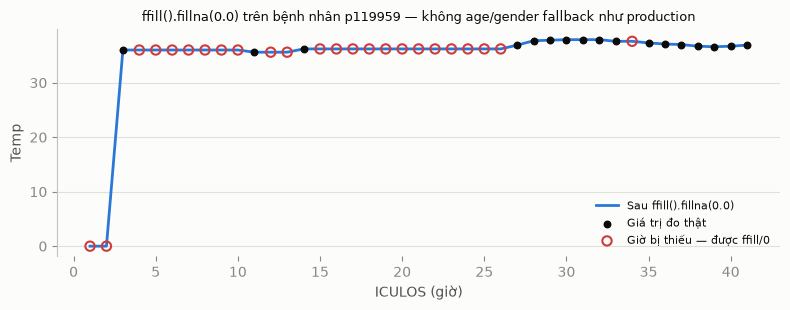

Số giờ đầu chuỗi phải fillna(0.0) vì chưa có phép đo nào để ffill: 2



**Phân tích:** 2 giờ đầu chuỗi của bệnh nhân này không có gì để `ffill` nên phải điền cứng 0.0 —
một giá trị Temp=0.0 hoàn toàn phi sinh lý, khác cách production xử lý cùng tình huống bằng
`fit_age_gender_normal_values` (điền theo median (Age, Gender) hợp lý về sinh lý). Baseline Sepsyd chấp nhận
đánh đổi này để giữ pipeline đơn giản, đồng nhất cho mọi cột — model phải tự học "0 ở đầu chuỗi" là tín hiệu
"chưa có dữ liệu" chứ không phải "giá trị đo được là 0", dựa vào chính mask đi kèm (mục 7).


In [10]:
def longest_nan_run(series: pd.Series) -> int:
    is_na = series.isna().to_numpy()
    best = current = 0
    for flag in is_na:
        current = current + 1 if flag else 0
        best = max(best, current)
    return best


run_lengths = raw_df.groupby("patient_id")["Temp"].apply(longest_nan_run)
in_band = run_lengths[(run_lengths >= 4) & (run_lengths <= 12)]
example_patient_id = (in_band if len(in_band) else run_lengths).sort_values(ascending=False).index[0]

patient_df = raw_df.loc[raw_df["patient_id"] == example_patient_id, ["ICULOS", "Temp"]].reset_index(drop=True)
was_missing = patient_df["Temp"].isna()
ffilled = patient_df["Temp"].ffill().fillna(0.0)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(patient_df["ICULOS"], ffilled, color=CAT[0], linewidth=2, label="Sau ffill().fillna(0.0)", zorder=2)
ax.scatter(patient_df.loc[~was_missing, "ICULOS"], patient_df.loc[~was_missing, "Temp"],
           color=INK["primary"], s=22, zorder=3, label="Giá trị đo thật")
ax.scatter(patient_df.loc[was_missing, "ICULOS"], ffilled[was_missing],
           facecolors="none", edgecolors=STATUS["critical"], s=45, linewidth=1.5, zorder=4,
           label="Giờ bị thiếu — được ffill/0")
ax.set_xlabel("ICULOS (giờ)")
ax.set_ylabel("Temp")
ax.set_title(f"ffill().fillna(0.0) trên bệnh nhân {example_patient_id} — không age/gender fallback như production", fontsize=9.5)
ax.legend(frameon=False, fontsize=8, loc="best")
style_ax(ax, grid_axis="y")
plt.tight_layout()
plt.show()

n_zero_filled = int(((was_missing) & (ffilled == 0.0)).sum())
print(f"Số giờ đầu chuỗi phải fillna(0.0) vì chưa có phép đo nào để ffill: {n_zero_filled}")

display(Markdown(f"""
**Phân tích:** {n_zero_filled} giờ đầu chuỗi của bệnh nhân này không có gì để `ffill` nên phải điền cứng 0.0 —
một giá trị Temp=0.0 hoàn toàn phi sinh lý, khác cách production xử lý cùng tình huống bằng
`fit_age_gender_normal_values` (điền theo median (Age, Gender) hợp lý về sinh lý). Baseline Sepsyd chấp nhận
đánh đổi này để giữ pipeline đơn giản, đồng nhất cho mọi cột — model phải tự học "0 ở đầu chuỗi" là tín hiệu
"chưa có dữ liệu" chứ không phải "giá trị đo được là 0", dựa vào chính mask đi kèm (mục 7).
"""))

## 10. Chuẩn hoá toàn cục (global mean/std) — có ổn định giữa Set A và Set B không


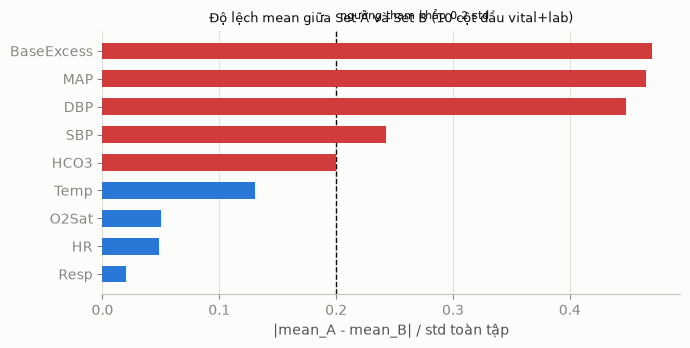

Số cột lệch > 0.2 std giữa 2 nguồn: 5/10



**Vì sao 1 bộ mean/std toàn cục vẫn chấp nhận được cho baseline này:** 5/10 cột lệch quá
ngưỡng 0.2 std giữa 2 nguồn. `fit_normalization_stats` gộp cả 2 nguồn khi tính mean/std duy nhất — nếu số cột
lệch nhiều, thống kê chung có thể che lấp khác biệt thật giữa 2 bệnh viện, ảnh hưởng tới cách đọc SHAP sau này
(khó tách bạch tín hiệu do bệnh lý với tín hiệu do nguồn dữ liệu). Số cột lệch hiện tại đáng chú ý, nên cân nhắc khi diễn giải kết quả SHAP theo nguồn dữ liệu.


In [11]:
compare_cols = (VITAL_SIGNS + LABS)[:10]
rows = []
for col in compare_cols:
    values = pd.to_numeric(raw_df[col], errors="coerce")
    mean_a = values[raw_df["source"] == "Set A"].mean()
    mean_b = values[raw_df["source"] == "Set B"].mean()
    std_pooled = values.std()
    rows.append({"column": col, "mean_A": mean_a, "mean_B": mean_b,
                 "lech_chuan_hoa": abs(mean_a - mean_b) / std_pooled if std_pooled else np.nan})

drift_df = pd.DataFrame(rows).set_index("column").sort_values("lech_chuan_hoa", ascending=True)

fig, ax = plt.subplots(figsize=(7, 3.6))
colors = [STATUS["critical"] if v > 0.2 else CAT[0] for v in drift_df["lech_chuan_hoa"]]
ax.barh(drift_df.index, drift_df["lech_chuan_hoa"], color=colors, height=0.6, zorder=3)
ax.axvline(0.2, color=INK["primary"], linewidth=1, linestyle="--")
ax.text(0.2, len(drift_df) - 0.5, " ngưỡng tham khảo 0.2 std", fontsize=8, va="top", color=INK["primary"])
ax.set_xlabel("|mean_A - mean_B| / std toàn tập")
ax.set_title("Độ lệch mean giữa Set A và Set B (10 cột đầu vital+lab)", fontsize=9)
style_ax(ax, grid_axis="x")
plt.tight_layout()
plt.show()

n_drifted = int((drift_df["lech_chuan_hoa"] > 0.2).sum())
print(f"Số cột lệch > 0.2 std giữa 2 nguồn: {n_drifted}/{len(drift_df)}")

display(Markdown(f"""
**Vì sao 1 bộ mean/std toàn cục vẫn chấp nhận được cho baseline này:** {n_drifted}/{len(drift_df)} cột lệch quá
ngưỡng 0.2 std giữa 2 nguồn. `fit_normalization_stats` gộp cả 2 nguồn khi tính mean/std duy nhất — nếu số cột
lệch nhiều, thống kê chung có thể che lấp khác biệt thật giữa 2 bệnh viện, ảnh hưởng tới cách đọc SHAP sau này
(khó tách bạch tín hiệu do bệnh lý với tín hiệu do nguồn dữ liệu). {'Số cột lệch hiện tại thấp nên rủi ro này nhỏ trên dữ liệu này.' if n_drifted <= 2 else 'Số cột lệch hiện tại đáng chú ý, nên cân nhắc khi diễn giải kết quả SHAP theo nguồn dữ liệu.'}
"""))

## 11. Độ phủ lookback H=5


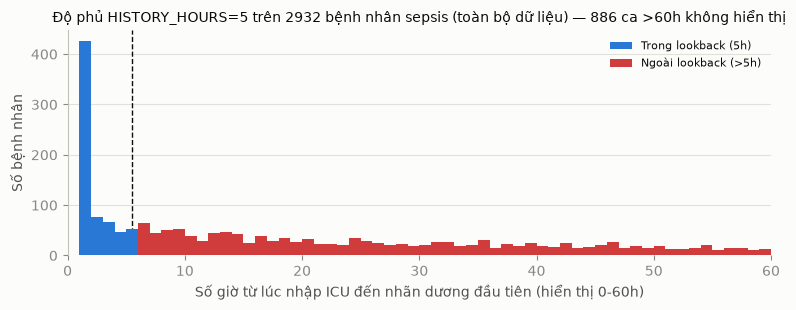

Tỷ lệ có nhãn dương đầu tiên trong 5 giờ đầu ICU: 22.8%



**Vì sao `add_lookback` đệm bằng 0 thay vì loại bỏ bệnh nhân thiếu lịch sử:** chỉ 22.8% bệnh nhân
sepsis có nhãn dương trong 5h đầu ICU — nhóm dương vốn đã cực hiếm (mục 2: tỷ lệ neg:pos ~55:1).
Loại thêm các ca thiếu đủ 5h lịch sử sẽ làm mất cân bằng lớp nghiêm trọng hơn nữa. Baseline Sepsyd
vì vậy giữ lại toàn bộ bệnh nhân, đệm 0 cho phần lịch sử thiếu — đúng cách production cũng chọn (`add_lookback`
trong `feature_builder.py`), dù 2 pipeline khác nhau ở mọi bước trước đó.


In [12]:
def first_positive_offset(group: pd.DataFrame):
    positive_hours = group.loc[group[LABEL_COLUMN] == 1, "ICULOS"]
    if positive_hours.empty:
        return np.nan
    return positive_hours.min() - group["ICULOS"].min() + 1


onset_offsets = (
    raw_df.groupby("patient_id")[["ICULOS", LABEL_COLUMN]]
    .apply(first_positive_offset, include_groups=False)
    .dropna()
)
within_lookback = float((onset_offsets <= HISTORY_HOURS).mean()) if len(onset_offsets) else float("nan")

DISPLAY_CAP = 60
max_hour = int(onset_offsets.max()) if len(onset_offsets) else HISTORY_HOURS
bins = np.arange(1, min(max_hour, DISPLAY_CAP) + 3)
covered = onset_offsets[onset_offsets <= HISTORY_HOURS]
uncovered = onset_offsets[(onset_offsets > HISTORY_HOURS) & (onset_offsets <= DISPLAY_CAP)]
n_beyond_cap = int((onset_offsets > DISPLAY_CAP).sum())

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(covered, bins=bins, color=CAT[0], zorder=3, label=f"Trong lookback ({HISTORY_HOURS}h)")
ax.hist(uncovered, bins=bins, color=STATUS["critical"], zorder=3, label=f"Ngoài lookback (>{HISTORY_HOURS}h)")
ax.axvline(HISTORY_HOURS + 0.5, color=INK["primary"], linewidth=1, linestyle="--")
ax.set_xlim(0, DISPLAY_CAP)
ax.set_xlabel(f"Số giờ từ lúc nhập ICU đến nhãn dương đầu tiên (hiển thị 0-{DISPLAY_CAP}h)")
ax.set_ylabel("Số bệnh nhân")
title = f"Độ phủ HISTORY_HOURS={HISTORY_HOURS} trên {len(onset_offsets)} bệnh nhân sepsis (toàn bộ dữ liệu)"
if n_beyond_cap:
    title += f" — {n_beyond_cap} ca >{DISPLAY_CAP}h không hiển thị"
ax.set_title(title, fontsize=10)
ax.legend(frameon=False, fontsize=8, loc="upper right")
style_ax(ax, grid_axis="y")
plt.tight_layout()
plt.show()

print(f"Tỷ lệ có nhãn dương đầu tiên trong {HISTORY_HOURS} giờ đầu ICU: {within_lookback:.1%}")

display(Markdown(f"""
**Vì sao `add_lookback` đệm bằng 0 thay vì loại bỏ bệnh nhân thiếu lịch sử:** chỉ {within_lookback:.1%} bệnh nhân
sepsis có nhãn dương trong {HISTORY_HOURS}h đầu ICU — nhóm dương vốn đã cực hiếm (mục 2: tỷ lệ neg:pos ~{ratio_actual:.0f}:1).
Loại thêm các ca thiếu đủ {HISTORY_HOURS}h lịch sử sẽ làm mất cân bằng lớp nghiêm trọng hơn nữa. Baseline Sepsyd
vì vậy giữ lại toàn bộ bệnh nhân, đệm 0 cho phần lịch sử thiếu — đúng cách production cũng chọn (`add_lookback`
trong `feature_builder.py`), dù 2 pipeline khác nhau ở mọi bước trước đó.
"""))

## 12. Tổng kết đối chiếu EDA ↔ Preprocess (`reproduce-xai.ipynb` / `model-comparison.ipynb`)

| Vấn đề EDA phát hiện (mục) | Xử lý trong `reproduce-xai.ipynb` | Ghi chú |
|---|---|---|
| Mất cân bằng lớp nặng (mục 2) | `weighted_logloss_objective` với `POSITIVE_WEIGHT` | Đối chiếu trực tiếp với tỷ lệ thực đo |
| Missing rất khác nhau giữa vital và lab (mục 3) | `preprocess_patient`: `ffill()` đồng loạt cho cả 40 cột | Khác production: production chỉ ffill 3 cột |
| Nhiều cặp cột tương quan cao (mục 4) | Không lọc/giảm chiều feature | Khác production (`model_feature_columns` loại cột không cần) |
| Không lọc outlier trước (mục 5) | Không có bước tương đương `filter_absolute_outliers` | Outlier có thể bị `ffill` lan truyền |
| Skew không đều giữa các cột (mục 6) | `signed_log1p` trên danh sách cố định `LOG_TRANSFORM_VARS` | Không tính động theo skew như `preprocessor.py` |
| "Có đo hay không" mang tín hiệu riêng (mục 7) | `mask = raw[MASKED_VARS].notna()` — 34 mask feature | Giữ tách biệt khỏi giá trị đã impute |
| Chuỗi liên tục theo patient_id (mục 8) | `ffill`/`add_lookback` group theo `patient_id` | Xác nhận đúng trên dữ liệu thật |
| Nhiều giờ đầu chuỗi chưa có phép đo (mục 9) | `ffill().fillna(0.0)` | Không có age/gender fallback như `cleaning.py` |
| Cần 1 bộ mean/std áp dụng toàn tập (mục 10) | `fit_normalization_stats` tính 1 lần trên toàn bộ train | Không chia theo fold như production |
| Độ phủ lookback (mục 11) | `add_lookback(hours=5)` | H=5 cố định theo đúng cấu hình đã công bố |

Không có mục nào ở trên được sửa trong `reproduce-xai.ipynb`/`model-comparison.ipynb` như một phần của EDA này —
đây thuần là bước lý giải, đúng phạm vi đã thống nhất.


## Phụ lục — Rủi ro/hạn chế của pipeline này (không sửa trong notebook EDA)

1. **Forward-fill đồng loạt 40 cột** (mục 3, 9) — với cột lab thiếu >90%, ffill có thể lan truyền 1 lần đo thành
   hàng chục/hàng trăm giờ dữ liệu "giả" — rủi ro lớn hơn production (chỉ ffill 3 cột đã kiểm chứng ổn định).
2. **Không lọc outlier sinh lý** trước ffill (mục 5) — giá trị rác có thể bị ffill lan truyền mà không qua bước
   kiểm tra nào, khác `filter_absolute_outliers` của production.
3. **`LOG_TRANSFORM_VARS` cố định** (mục 6) — chấp nhận được vì mục tiêu là tái lập trung thực, nhưng không phải
   "tối ưu cho dữ liệu hiện tại".
4. **Không lọc/giảm chiều feature tương quan cao** (mục 4) — có thể làm loãng SHAP importance giữa các cột
   tương quan thay vì dồn vào 1 cột đại diện.
5. **Chuẩn hoá toàn cục** (mục 10) — nếu 2 nguồn dữ liệu lệch nhiều, khó tách bạch tín hiệu bệnh lý với tín hiệu
   do nguồn dữ liệu khi đọc kết quả SHAP.

Không có mục nào ở trên được sửa trong `reproduce-xai.ipynb`/`model-comparison.ipynb` như một phần của EDA này.
